<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **Catalogue Data: Query with Constraints**

This notebook demonstrates two simple ways to work with ESO catalogue tables using `astroquery.eso`. 

First, we run a compact query with a basic magnitude constraint. Then we inspect a ``VIKING`` catalogue, select a few useful photometric columns, and build a simple colour-colour diagram.

<hr style="border:2px solid #0281c9"> </hr>

# **Importing and basic usage of astroquery.eso**

In [1]:
import astroquery # import astroquery
print(f"astroquery version: {astroquery.__version__}") # check the version of astroquery

astroquery version: 0.4.12.dev505+gf2a77a615.d20260427


In [2]:
from astroquery.eso import Eso # import the ESO module from astroquery

In [3]:
eso = Eso() # create an instance of the ESO class

# **A simple constrained catalogue query**

As a first example, we query the `KiDS_DR4_1_ugriZYJHKs_cat_fits` catalogue and retrieve only a small subset of the available columns (see [Kilo Degree Survey](https://www.eso.org/rm/api/v1/public/releaseDescriptions/151)). 

In [4]:
catalog_name = "KiDS_DR4_1_ugriZYJHKs_cat_fits" # choose one catalogue table

As with the other query helpers, it is often useful to inspect the available columns first using `help=True`.

In [5]:
eso.query_catalog(catalog=catalog_name, help=True) # inspect the available columns

INFO: 
Columns present in the table safcat.KiDS_DR4_1_ugriZYJHKs_cat_fits:
    column_name     datatype       unit                        ucd                 
------------------- -------- ---------------- -------------------------------------
                 ID     CHAR                                      meta.id;meta.main
          KIDS_TILE     CHAR                                                meta.id
         THELI_NAME     CHAR                                                meta.id
              SeqNr  INTEGER                                                meta.id
               SLID  INTEGER                                                meta.id
                SID  INTEGER                                                meta.id
          FLUX_AUTO     REAL            count                    phot.flux;em.opt.R
       FLUXERR_AUTO     REAL            count         stat.error;phot.flux;em.opt.R
           MAG_AUTO     REAL              mag                     phot.mag;em.opt.R
 

The `column_filters` dictionary accepts ADQL-style constraints (as with e.g. `eso.query_main` and `query_surveys`), so here we constrain for bright sources with `MAG_AUTO < 10`.

We also set a row limit for the query to keep the result manageable, but you can increase it or set `ROW_LIMIT=None` if you want the full result set.

In [6]:
eso.ROW_LIMIT = 20 # set a row limit for the query

table = eso.query_catalog(
    catalog=catalog_name,
    columns=["ID", "RAJ2000", "DECJ2000", "KIDS_TILE", "MAG_AUTO", "MAGERR_AUTO"],
    column_filters={"MAG_AUTO": "<10"},
    )

table

ID,RAJ2000,DECJ2000,KIDS_TILE,MAG_AUTO,MAGERR_AUTO
,deg,deg,,mag,mag
object,float64,float64,object,float32,float32
KiDSDR4 J092035.791+001110.92,140.14913,0.186369,KIDS_140.0_0.5,9.263525,3.264208e-05
KiDSDR4 J110654.466+015628.34,166.726944,1.941208,KIDS_167.0_1.5,9.844576,4.391666e-05
KiDSDR4 J225722.767-293856.66,344.34486300000003,-29.649074,KIDS_344.1_-29.2,9.725844,0.0001094358
KiDSDR4 J225758.638-293926.33,344.494327,-29.657316,KIDS_344.1_-29.2,9.977708,5.690645e-05
KiDSDR4 J225800.313-293912.97,344.501307,-29.653605,KIDS_344.1_-29.2,9.987597,6.199808e-05
KiDSDR4 J225735.322-293704.00,344.397179,-29.617778,KIDS_344.1_-29.2,8.625019,3.714558e-05
KiDSDR4 J225744.889-293707.29,344.437039,-29.618693,KIDS_344.1_-29.2,9.035948,4.698832e-05
KiDSDR4 J225742.604-293659.72,344.427517,-29.616588999999998,KIDS_344.1_-29.2,8.463177,3.426704e-05


## **Optional: Inspecting all catalogues from a given telescope/instrument**

Here we query for the available (latest) catalogues from the [ESO-VISTA telescope](https://www.eso.org/sci/facilities/paranal/telescopes/vista.html), making use of the free TAP query method `query_tap()`.

More information on how to use `query_tap()` can be found in the [ESO TAP tutorial notebook](10_catalogs_query_tap.ipynb).

In [7]:
query = """
        SELECT collection, table_name, title, version, instrument, telescope
        FROM TAP_SCHEMA.tables
        WHERE cat_id in 
                    (select t1.cat_id cat_id 
                    from TAP_SCHEMA.tables t1
                    left outer join TAP_SCHEMA.tables t2 on (t1.title = t2.title and t1.version< t2.version) 
                    where t2.title is null)
        ORDER BY schema_name, collection, title
        """

table_info = eso.query_tap(query, tap_endpoint="tap_cat")

vista_filter = (table_info['telescope'] == 'ESO-VISTA') | (table_info['telescope'] == 'ESO-VST, ESO-VISTA') # Filter the VISTA catalogues
vista_catalogues_info = table_info.copy()[vista_filter] 
vista_catalogues_info[:3]

collection,table_name,title,version,instrument,telescope
object,object,object,int32,object,object
GCAV,gcav_rxcj1515_YJKs_cat_fits_V1,GCAV catalogue for RXCJ1514.9-1523 cluster,1,VIRCAM,ESO-VISTA
GCAV,gcav_rxcj2129_YJKs_cat_fits_V1,GCAV catalogue for RXCJ2129.6+0005 cluster,1,VIRCAM,ESO-VISTA


We can now query across all VISTA catalogues and work with the results as neeeded. 

Here we simply retrieve the first row of the first VISTA catalogue, but this pattern can be adapted to inspect all catalogues and their columns.

In [8]:
eso.ROW_LIMIT = 1

table_names = list(vista_catalogues_info["table_name"])[0:2]  # Get the first VISTA catalogue name
table_dict = {}
for table_name in table_names:
    table_dict[table_name] = eso.query_catalog(catalog=table_name)
table_dict

{'gcav_rxcj1515_YJKs_cat_fits_V1': <Table length=1>
       DECJ2000      J_A_IMAGE J_BACKGROUND ... Y_SPREAD_MODEL Y_THETA_IMAGE
         deg           pixel      count     ...                     deg     
       float64        float32    float32    ...    float32        float32   
 ------------------- --------- ------------ ... -------------- -------------
 -15.682308633333335     2.041    0.3032899 ...       0.010883         44.03,
 'gcav_rxcj2129_YJKs_cat_fits_V1': <Table length=1>
       DECJ2000      J_A_IMAGE J_BACKGROUND ... Y_SPREAD_MODEL Y_THETA_IMAGE
         deg           pixel      count     ...                     deg     
       float64        float32    float32    ...    float32        float32   
 ------------------- --------- ------------ ... -------------- -------------
 -0.3017760333333333     2.403   -0.1548975 ...     0.00085715         -1.78}

# **Finding and inspecting a VIKING catalogue**

As an additional example, below we look for catalogue names containing `VIKING`, then inspect the schema of one VIKING catalogue before selecting a small set of columns for exploration. 

To keep the query reasonably light, as before we retrieve only subset of columns (only need the source classification and three aperture magnitudes) and cap the result size at `10000` rows. 

Note however, that here we make use of the `top` keyword in the `query_catalog()` method, which is an alternative way to set a row limit for the query.

We then compute two colours, `J - K_s` and `Z - J`, and compare stars with extended sources using a kernel-density estimate.

In [9]:
# few additional imports for the colour-colour plot
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [10]:
viking_catalog = [name for name in eso.list_catalogs(all_versions=False) if "VIKING" in name.upper()][0]
viking_catalog

'viking_er5_zyjj_1j_2hks_catMetaData_fits_V4'

In [11]:
selected_columns = ["MERGEDCLASS", "ZAPERMAG3", "JAPERMAG3", "KSAPERMAG3"]

eso.ROW_LIMIT = None # remove the row limit for this query

viking = eso.query_catalog(
    catalog=viking_catalog,
    columns=selected_columns,
    top=10000, # set a row limit for the query using the 'top' keyword
)

# Compute the colours and filter out rows with masked values
class_star = np.ma.asarray(viking["MERGEDCLASS"])
jk = np.ma.asarray(viking["JAPERMAG3"]) - np.ma.asarray(viking["KSAPERMAG3"])
zj = np.ma.asarray(viking["ZAPERMAG3"]) - np.ma.asarray(viking["JAPERMAG3"])

valid = ~(
    np.ma.getmaskarray(class_star)
    | np.ma.getmaskarray(jk)
    | np.ma.getmaskarray(zj)
)

class_star = np.asarray(class_star[valid])
jk = np.asarray(jk[valid])
zj = np.asarray(zj[valid])

## **Plot a colour-colour diagram**

**Function:** ``plot_kde`` Below we define a simple function to compute the kernel-density estimate for a given set of points, which we will use to compare the distribution of stars and extended sources in colour-colour space. The function takes two arrays of x and y values, computes the 2D KDE, and returns the grid and density values for plotting.

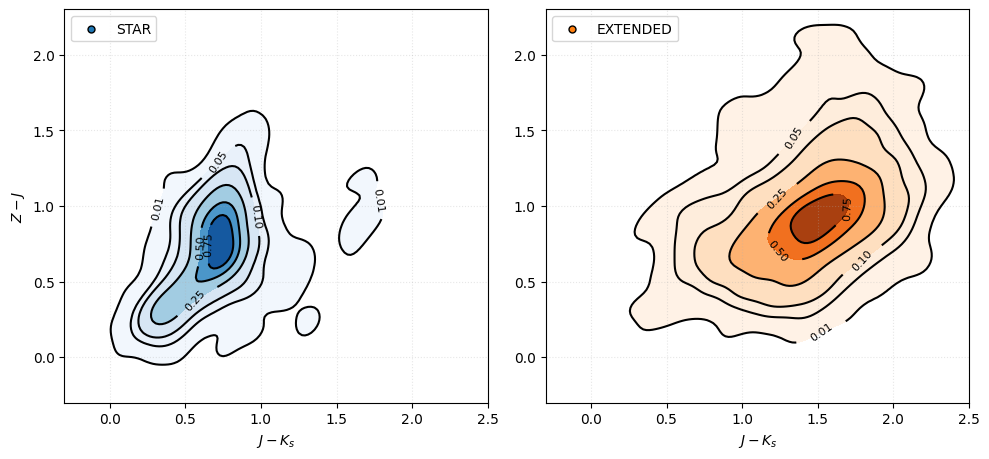

In [12]:
def plot_kde(ax, x, y, xmin, xmax, ymin, ymax, cmap="Blues"):
    """Compute and plot a normalized 2D Gaussian KDE of (x, y) as contours.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to draw on.
    x, y : array-like
        1D samples of the two variables.
    xmin, xmax, ymin, ymax : float
        Plotting bounds defining the evaluation grid.
    cmap : str, optional
        Colormap for filled contours (default: "Blues").

    Returns
    -------
    matplotlib.axes.Axes
        The axes with KDE contours added.
    """
    xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x, y])

    kernel = stats.gaussian_kde(values)
    kde = np.reshape(kernel(positions).T, xx.shape)
    kde = kde / np.max(kde)

    levels = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1]

    ax.contourf(xx, yy, kde, levels=levels, cmap=cmap, vmin=0, alpha=0.95)
    contours = ax.contour(xx, yy, kde, levels=levels, colors="k")
    ax.clabel(contours, inline=1, fontsize=8)

    return ax

fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, sharex=ax1, sharey=ax1)

ax1.set_aspect("equal")
ax2.set_aspect("equal")

mask_star = class_star == -1

plot_kde(ax1, jk[mask_star], zj[mask_star], xmin=-1, xmax=3, ymin=-1, ymax=3, cmap="Blues")
plot_kde(ax2, jk[~mask_star], zj[~mask_star], xmin=-1, xmax=3, ymin=-1, ymax=3, cmap="Oranges")

ax1.scatter(np.nan, np.nan, label="STAR", fc="C0", ec="k", marker=".", s=100)
ax2.scatter(np.nan, np.nan, label="EXTENDED", fc="C1", ec="k", marker=".", s=100)

for ax in [ax1, ax2]:
    ax.set_xlim(-0.3, 2.5)
    ax.set_ylim(-0.3, 2.3)
    ax.set_xlabel(r"$J - K_s$")
    ax.legend(loc="upper left")
    ax.grid(True, ls=":", alpha=0.3)

ax1.set_ylabel(r"$Z - J$")

plt.tight_layout()

<hr style="border:2px solid #0281c9"> </hr>